id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64
Epoch 1/100, Training Loss: 419096050928.4174, Validation Loss: 414503719517.4957
Epoch 2/100, Training Loss: 393099501710.4695, Validation Loss: 365505848791.9304
Epoch 3/100, Training Loss: 317350752024.4869, Validation Loss: 267675056110.1913
Epoch 4/100, Training Loss: 216905210951.2348, Validation Loss: 173079600760.2087
Epoch 5/100, Training Loss: 142321515092.5913, Validation Loss: 119453884113.2522
Epoch 6/100, Training Loss: 108226301876.3130, Validation Loss: 98750572668.6609
Epoch 7/100, Training Loss: 95334754397.4957, Validation Loss: 89535965201.8087
Epoch 8/100, Trai

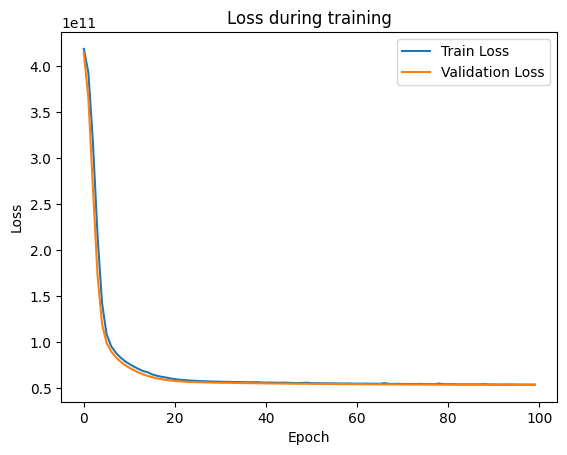

Test Loss: 64231950506.6667


In [2]:
# 1. Importar las librerías necesarias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# 2. Cargar los datos
data = pd.read_csv('/workspace/dataset.csv')

# Eliminar espacios en los nombres de las columnas
data.columns = data.columns.str.strip()

# Verificar y eliminar filas con valores nulos en las columnas necesarias
data = data.dropna(subset=['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'yr_built', 'price'])

# Verificar que no queden valores nulos
print(data.isnull().sum())

# 3. Definir las características numéricas y la variable objetivo
numeric_features = ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'yr_built']
target = 'price'

# 4. Dividir los datos en entrenamiento, validación y prueba
train_data, test_data = train_test_split(data, test_size=0.15, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.2, random_state=42)

# 5. Normalización de las características
scaler = StandardScaler()
train_data[numeric_features] = scaler.fit_transform(train_data[numeric_features])
val_data[numeric_features] = scaler.transform(val_data[numeric_features])
test_data[numeric_features] = scaler.transform(test_data[numeric_features])

# 6. Convertir los datos a tensores de PyTorch
X_train = torch.tensor(train_data[numeric_features].values, dtype=torch.float32)
y_train = torch.tensor(train_data[target].values, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(val_data[numeric_features].values, dtype=torch.float32)
y_val = torch.tensor(val_data[target].values, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(test_data[numeric_features].values, dtype=torch.float32)
y_test = torch.tensor(test_data[target].values, dtype=torch.float32).unsqueeze(1)

# 7. Crear DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False, num_workers=4)

# 8. Definir el modelo Feed-Forward en PyTorch
class FeedForwardNN(nn.Module):
    def __init__(self):
        super(FeedForwardNN, self).__init__()
        self.fc1 = nn.Linear(len(numeric_features), 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

# Instanciar el modelo
model = FeedForwardNN()

# 9. Definir la función de coste (MSE) y el optimizador (Adam con weight_decay)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)

# 10. Entrenamiento del modelo
epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_losses.append(train_loss / len(train_loader))
    
    # Validación en cada época
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            val_loss += loss.item()
    val_losses.append(val_loss / len(val_loader))

    # Imprimir los resultados de la época
    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}")

# 11. Graficar la curva de pérdida
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Loss during training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 12. Evaluación del modelo en el conjunto de prueba
model.eval()
test_loss = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        test_loss += loss.item()

print(f"Test Loss: {test_loss / len(test_loader):.4f}")
